Created By Yongtao Liu

Summer Project for Jiawei Gong and Mallory Pierce

# ENGAGEGP: Gaussian Process Regression (GPR) on 2D synthetic data

This notebook demonstrates **ENGAGEGP** regression on a simple 2D synthetic field.

We compare:
- **Standard GP** (no deep kernel): `extractor_type=None`
- **Attention feature extractor**: `extractor_type='attention'`
- **Direct attention extractor**: `extractor_type='direct_attention'`

All models are trained with `engagegp.fit_dkgp` and predicted with `engagegp.predict_dkgpr`.


## Setup
If you run this notebook in a fresh environment, install dependencies first:


## Imports and configuration

This cell imports the required libraries and sets basic plotting + RNG seeds.
- `engagegp` provides the GP fitting/prediction utilities used throughout.
- `torch` is used for model training under the hood (even for pure GP mode).

Tip: run this cell first after restarting the kernel.


In [207]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import engagegp as egp

plt.rcParams.update({'figure.figsize': (7, 5)})

torch.manual_seed(0)
np.random.seed(0)


## Reproducibility

This cell locks randomness so results are repeatable.
- `SEED` controls NumPy + Torch RNG streams.
- Separate `default_rng(SEED + k)` streams are used later for different randomized stages (init sampling vs active learning).

If you change `SEED`, rerun the notebook from the top.


In [208]:
# Reproducibility
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)

# Use seeded NumPy Generator wherever we need randomness
rng = np.random.default_rng(SEED)


## Objective functions (ground truth)

These functions define the *unknown* objective we pretend to observe through noisy samples.
- **Rosenbrock**: classic non-convex valley; minimum at `(1, 1)`.
- **Levy**: multi-modal benchmark; minimum at `(1, 1)`.

In the active learning section, the GP is trained on noisy evaluations of this objective.


In [209]:
def rosenbrock(x, y):
    """Rosenbrock function. Global minimum f(1, 1) = 0."""
    return (1 - x)**2 + 100 * (y - x**2)**2

def levy(x, y):
    """Levy function. Global minimum f(1, 1) = 0."""
    w1 = 1 + (x - 1) / 4
    w2 = 1 + (y - 1) / 4
    term1 = np.sin(np.pi * w1)**2
    term2 = (w1 - 1)**2 * (1 + 10 * np.sin(np.pi * w1 + 1)**2)
    term3 = (w2 - 1)**2 * (1 + np.sin(2 * np.pi * w2)**2)
    return term1 + term2 + term3


## Choose objective

Select which benchmark function to emulate as the data-generating process.
This choice affects:
- the ground-truth field on the grid
- the sampled observations used to train the GP
- the active learning trajectory


In [210]:
# Choose objective: 'rosenbrock' or 'levy'
objective = 'rosenbrock'


## Build a 2D candidate grid

We build a uniform 2D grid in `[0, 1] × [0, 1]`:
- `grid_1d` is the 1D axis
- `gx, gy` are 2D mesh grids for plotting
- `grid_xy_np` is the flattened list of candidate points (shape: `(grid_size^2, 2)`)

This same grid is used for both prediction visualization and active learning candidate selection.


In [211]:
grid_size = 100
grid_1d = np.linspace(0, 1, grid_size, dtype=np.float64)
gx, gy = np.meshgrid(grid_1d, grid_1d, indexing='xy')
grid_xy_np = np.stack([gx, gy], axis=-1).reshape(-1, 2).astype(np.float64)


## Create initial training data (noisy samples)

This cell constructs the initial dataset used to fit the GP models:
- `X_all_np`: full candidate set (NumPy)
- `y_all_np`: ground-truth objective values on the full grid (NumPy)
- `X_train_np`: randomly selected initial inputs
- `y_obs_np`: noisy observations at those inputs
- `X_train_t`, `y_train_t`, `X_all_t`: Torch tensors used by ENGAGEGP

Note the separation of NumPy (`*_np`) for ground truth vs Torch (`*_t`) for modeling.


In [212]:
n_init = 50
noise_std = 0.05

# Candidate set (NumPy)
X_all_np = grid_xy_np.copy()

# Ground-truth values on the full grid (NumPy)
if objective == 'rosenbrock':
    y_all_np = rosenbrock(X_all_np[:, 0], X_all_np[:, 1])
elif objective == 'levy':
    y_all_np = levy(X_all_np[:, 0], X_all_np[:, 1])
else:
    raise ValueError(f'Unknown objective: {objective!r}')

# Initialize with random samples
rng_init = np.random.default_rng(SEED + 1)
init_idx = rng_init.choice(len(X_all_np), size=n_init, replace=False)
X_train_np = X_all_np[init_idx]

# Observations at sampled points (NumPy)
if objective == 'rosenbrock':
    y_true = rosenbrock(X_train_np[:, 0], X_train_np[:, 1])
else:
    y_true = levy(X_train_np[:, 0], X_train_np[:, 1])

y_obs_np = y_true + rng_init.normal(0.0, noise_std, size=y_true.shape)

# Torch tensors for model fitting/prediction
X_train_t = torch.from_numpy(X_train_np)
y_train_t = torch.from_numpy(y_obs_np)
X_all_t = torch.from_numpy(X_all_np)


## Visualize ground truth

This plot shows the underlying objective value over the entire grid.
It is only available because this is a synthetic example.
In real experiments, you would *not* know this field everywhere.


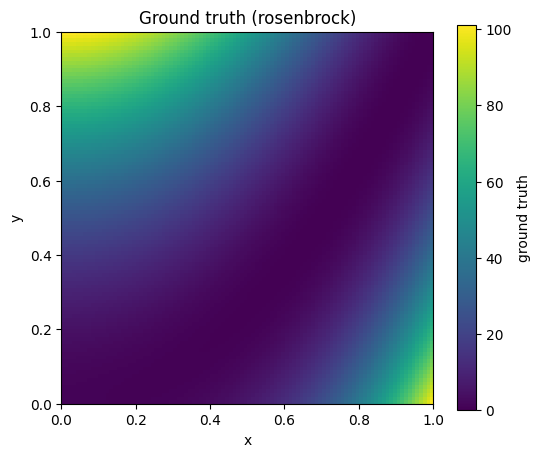

In [213]:
plt.figure(figsize=(6, 5))
plt.imshow(y_all_np.reshape((grid_size, grid_size)), origin='lower', extent=(0, 1, 0, 1), cmap='viridis')
plt.colorbar(label='ground truth')
plt.title(f'Ground truth ({objective})')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Train pure GP models

All models below use `extractor_type=None` so the GP kernel operates on the original 2D inputs.


## Fit pure GP models (kernel acts on X)

All model fits here use `extractor_type=None`, meaning **no deep feature extractor** is used and the GP kernel operates directly on the original 2D inputs `X`.

We compare several *pure GP* variants:
- **Standard GP**: `gp_kernel_type=base_kernel` (e.g., RBF or Matérn)
- **Sample-weighted GP**: `learn_sample_weights=True` downweights unreliable training points during fitting
- **Kernel direct attention**: `gp_kernel_type='direct_attention'` learns a mixing matrix inside the kernel (captures cross-dimension interactions)
- **Kernel attention weighted**: `gp_kernel_type='attention_weighted'` learns per-dimension importance weights inside the kernel

Notes on hyperparameters:
- `num_epochs` / `lr_gp` control optimization of kernel + likelihood parameters (and any kernel-attention parameters).
- Loss curves across different kernels are not directly comparable in absolute scale; focus on predictive behavior.


In [214]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# Choose the base GP kernel. Options: 'rbf', 'matern', 'matern_12', 'matern_32', 'matern_52'
base_kernel = 'rbf'
matern_nu = 2.5  # only used when base_kernel == 'matern'

# Pure-GP fit settings (no deep feature extractor is used because extractor_type=None)
common_fit_kwargs = dict(
    num_epochs=5000,
    lr_gp=5e-3,
    device=device,
    verbose=True,
)

# 1) Standard GP (pure GP): extractor_type=None
mll_std, gp_std, model_std, losses_std = egp.fit_dkgp(
    X_train_t, y_train_t,
    extractor_type=None,
    gp_kernel_type=base_kernel,
    matern_nu=matern_nu,
    **common_fit_kwargs,
)

# 2) Standard GP + sample-level attention (still pure GP)
# This keeps the GP in the original input space but learns per-sample weights.
mll_std_sw, gp_std_sw, model_std_sw, losses_std_sw, sample_w_std = egp.fit_dkgp(
    X_train_t, y_train_t,
    extractor_type=None,
    gp_kernel_type=base_kernel,
    matern_nu=matern_nu,
    learn_sample_weights=True,
    sample_weight_lr=0.05,
    **common_fit_kwargs,
)

# 3) Pure GP + direct attention IN THE KERNEL (GP acts on X)
mll_gp_datt, gp_gp_datt, model_gp_datt, losses_gp_datt = egp.fit_dkgp(
    X_train_t, y_train_t,
    extractor_type=None,
    gp_kernel_type='direct_attention',
    **common_fit_kwargs,
)

# 4) Pure GP + attention-weighted IN THE KERNEL (GP acts on X)
mll_gp_aw, gp_gp_aw, model_gp_aw, losses_gp_aw = egp.fit_dkgp(
    X_train_t, y_train_t,
    extractor_type=None,
    gp_kernel_type='attention_weighted',
    **common_fit_kwargs,
)


device: cpu
Training Standard GP (no deep kernel)

Auto-selected: ExactMarginalLogLikelihood

Training Standard GP (no deep kernel)
  Device: cpu
  Extractor type: None (standard GP)
  Input dim: 2 → Feature dim: 2
  Data points: 50
  MLL: ExactMarginalLogLikelihood
  Epoch  100/5000, Loss: 130.0127
  Epoch  200/5000, Loss: 83.8555
  Epoch  300/5000, Loss: 62.1718
  Epoch  400/5000, Loss: 49.0111
  Epoch  500/5000, Loss: 40.1901
  Epoch  600/5000, Loss: 33.9354
  Epoch  700/5000, Loss: 29.3099
  Epoch  800/5000, Loss: 25.7718
  Epoch  900/5000, Loss: 22.9899
  Epoch 1000/5000, Loss: 20.7520
  Epoch 1100/5000, Loss: 18.9174
  Epoch 1200/5000, Loss: 17.3890
  Epoch 1300/5000, Loss: 16.0983
  Epoch 1400/5000, Loss: 14.9958
  Epoch 1500/5000, Loss: 14.0445
  Epoch 1600/5000, Loss: 13.2207
  Epoch 1700/5000, Loss: 12.5538
  Epoch 1800/5000, Loss: 12.0102
  Epoch 1900/5000, Loss: 11.5518
  Epoch 2000/5000, Loss: 11.1560
  Epoch 2100/5000, Loss: 10.8081
  Epoch 2200/5000, Loss: 10.4980
  Epoc

## Training loss overlay

This overlays the negative marginal log likelihood (NLL) vs epoch for selected models.

Interpreting these curves:
- Non-monotonic behavior can happen with Adam and higher learning rates.
- Different kernels can have different loss scales, so compare trends rather than absolute values.

If curves look unstable, try lowering `lr_gp` or reducing model flexibility (e.g., prefer baseline kernels).


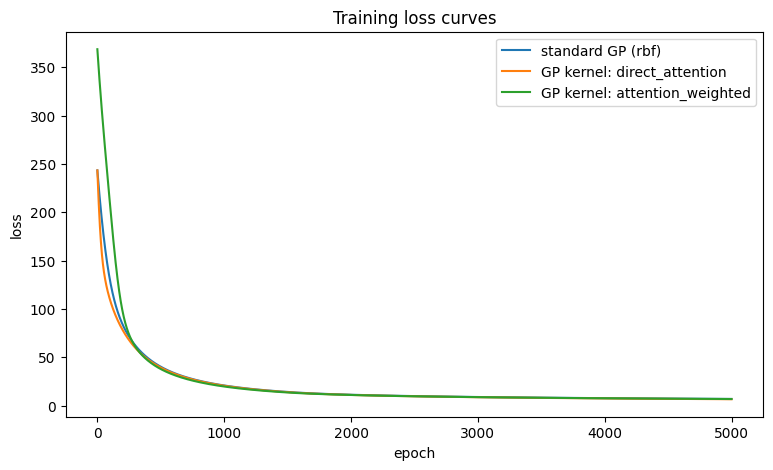

In [215]:
# Plot training losses (overlay)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(losses_std, label=f'standard GP ({base_kernel})')
ax.plot(losses_gp_datt, label='GP kernel: direct_attention')
ax.plot(losses_gp_aw, label='GP kernel: attention_weighted')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('Training loss curves')
ax.legend()
plt.show()


## Inspect learned attention parameters

For the *kernel-attention* models, we can directly inspect what was learned:
- `attention_weighted`: a 2-element softmax weight vector for `(x, y)`
- `direct_attention`: a 2×2 mixing matrix `W` used before distance computation

These are the closest analogs to “attention” in a pure-GP setting (no DKL feature network).


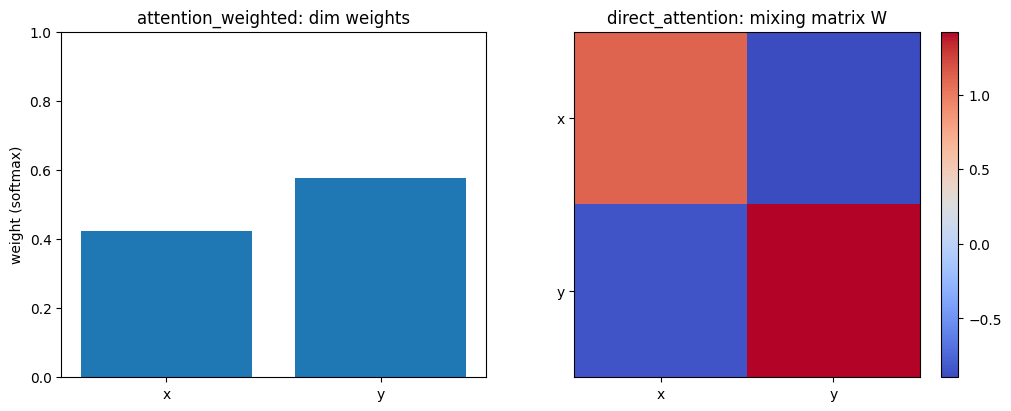

In [216]:
# Plot learned kernel-attention parameters

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# attention_weighted: per-dimension weights
try:
    w = torch.softmax(
        model_gp_aw.gp_model.covar_module.base_kernel.raw_attention_weights, dim=0
    ).detach().cpu().numpy()
    axes[0].bar([0, 1], w)
    axes[0].set_xticks([0, 1], ['x', 'y'])
    axes[0].set_ylim(0, 1)
    axes[0].set_title('attention_weighted: dim weights')
    axes[0].set_ylabel('weight (softmax)')
except Exception as e:
    axes[0].axis('off')
    axes[0].set_title(f'weights not available: {type(e).__name__}')

# direct_attention: mixing matrix
try:
    W = model_gp_datt.gp_model.covar_module.base_kernel.mixing_matrix.detach().cpu().numpy()
    im = axes[1].imshow(W, cmap='coolwarm')
    axes[1].set_title('direct_attention: mixing matrix W')
    axes[1].set_xticks([0, 1], ['x', 'y'])
    axes[1].set_yticks([0, 1], ['x', 'y'])
    fig.colorbar(im, ax=axes[1])
except Exception as e:
    axes[1].axis('off')
    axes[1].set_title(f'W not available: {type(e).__name__}')

plt.show()


## Posterior prediction on the full grid

We evaluate each trained GP model on all grid points:
- `mean_*`: posterior mean predictions
- `var_*`: posterior variance predictions
- `std_*`: posterior standard deviation (uncertainty)

We then reshape these vectors back to `(grid_size, grid_size)` for plotting as 2D images.


In [217]:
# Predict on the grid with ENGAGEGP

mean_std, var_std = egp.predict_dkgpr(model_std, X_all_t, device=device)
mean_std_sw, var_std_sw = egp.predict_dkgpr(model_std_sw, X_all_t, device=device)
mean_gp_datt, var_gp_datt = egp.predict_dkgpr(model_gp_datt, X_all_t, device=device)
mean_gp_aw, var_gp_aw = egp.predict_dkgpr(model_gp_aw, X_all_t, device=device)

std_std = np.sqrt(var_std)
std_std_sw = np.sqrt(var_std_sw)
std_gp_datt = np.sqrt(var_gp_datt)
std_gp_aw = np.sqrt(var_gp_aw)

Z_mean_std = mean_std.reshape(len(grid_1d), len(grid_1d))
Z_std_std = std_std.reshape(len(grid_1d), len(grid_1d))

Z_mean_std_sw = mean_std_sw.reshape(len(grid_1d), len(grid_1d))
Z_std_std_sw = std_std_sw.reshape(len(grid_1d), len(grid_1d))

Z_mean_gp_datt = mean_gp_datt.reshape(len(grid_1d), len(grid_1d))
Z_std_gp_datt = std_gp_datt.reshape(len(grid_1d), len(grid_1d))

Z_mean_gp_aw = mean_gp_aw.reshape(len(grid_1d), len(grid_1d))
Z_std_gp_aw = std_gp_aw.reshape(len(grid_1d), len(grid_1d))


## Compare posterior means

Each panel shows the posterior mean over the 2D domain.
White points indicate the training sample locations used for fitting.

Look for:
- how well the model captures valleys/peaks
- whether kernel-attention variants adapt better to the objective geometry


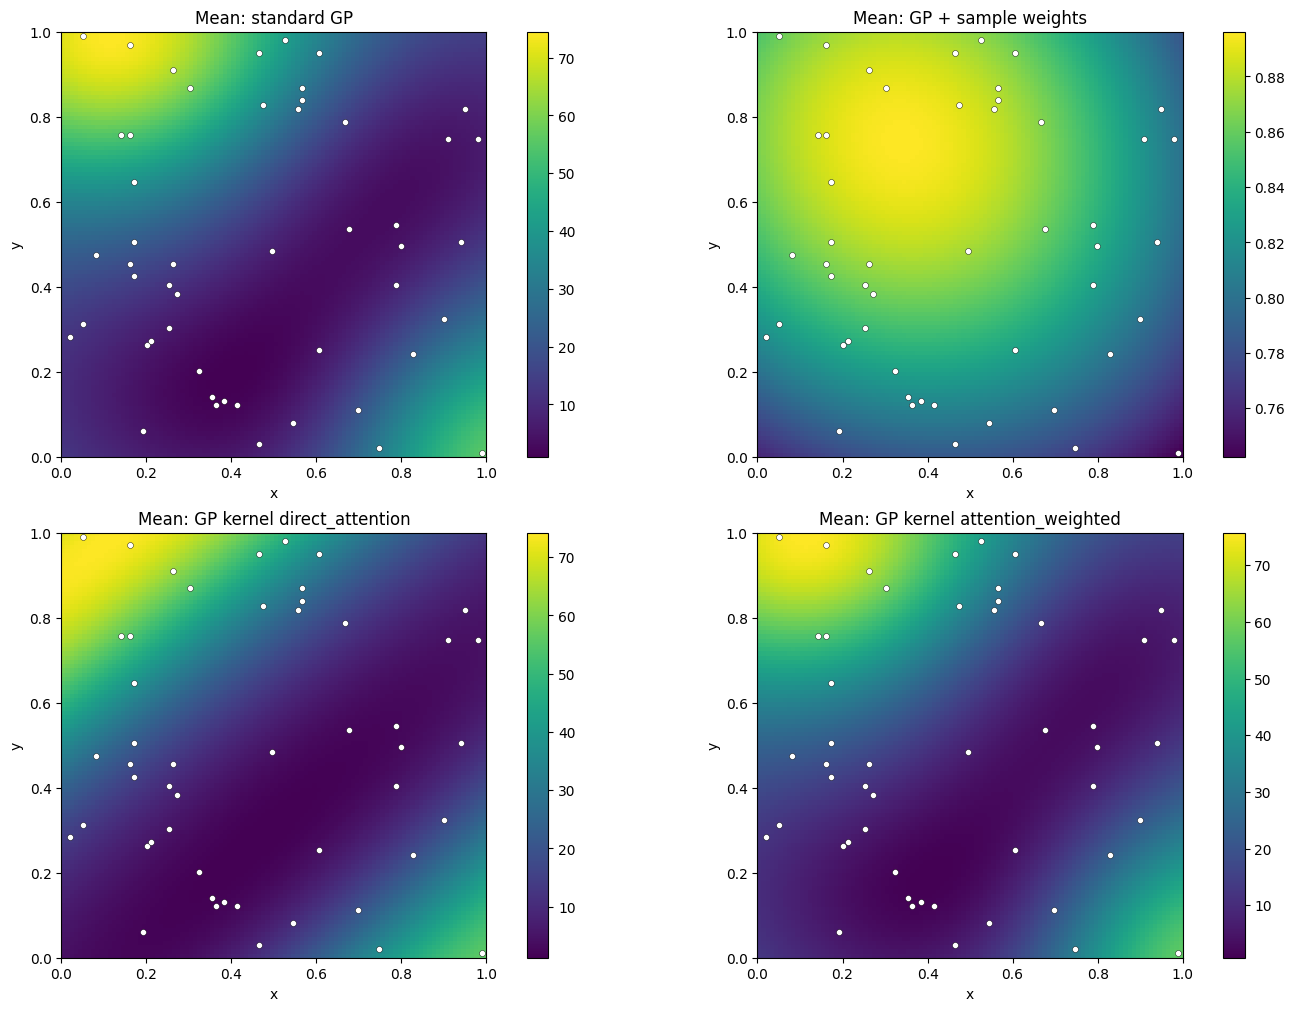

In [218]:
# Compare posterior means

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

panels = [
    (axes[0, 0], Z_mean_std, 'Mean: standard GP'),
    (axes[0, 1], Z_mean_std_sw, 'Mean: GP + sample weights'),
    (axes[1, 0], Z_mean_gp_datt, 'Mean: GP kernel direct_attention'),
    (axes[1, 1], Z_mean_gp_aw, 'Mean: GP kernel attention_weighted'),
]

for ax, Z, title in panels:
    im = ax.imshow(Z, origin='lower', extent=(0, 1, 0, 1), cmap='viridis')
    fig.colorbar(im, ax=ax)
    ax.scatter(X_train_np[:, 0], X_train_np[:, 1], c='white', s=18, edgecolor='k', linewidth=0.3)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.show()


## Compare uncertainties

Each panel shows posterior uncertainty (standard deviation).
A well-calibrated GP typically shows:
- low uncertainty near observed samples
- higher uncertainty in regions far from observations

Kernel-attention mechanisms may change the shape/orientation of uncertainty contours.


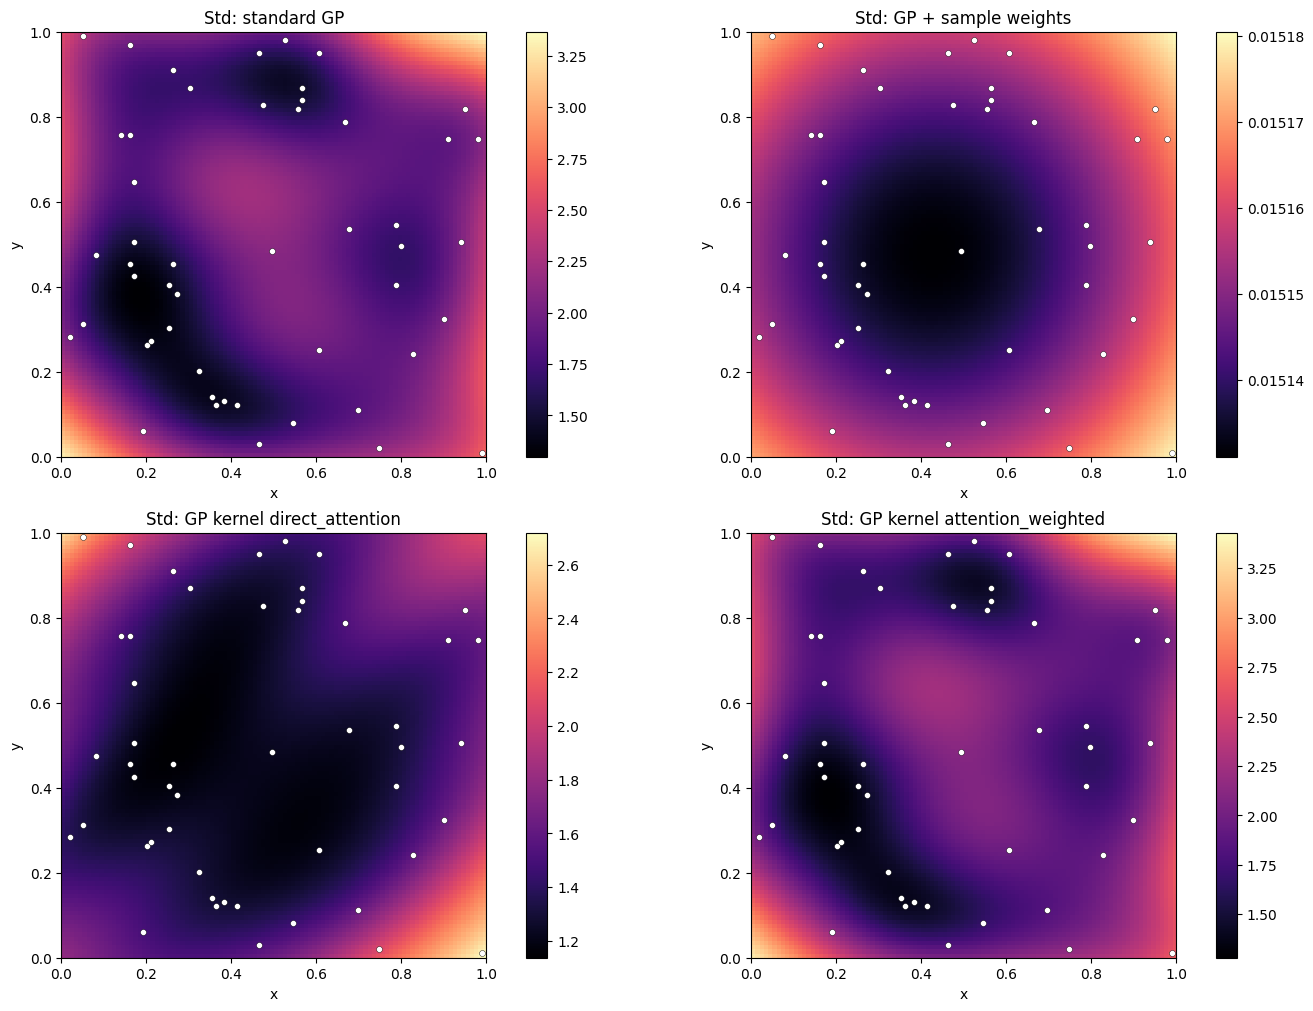

In [219]:
# Compare uncertainties (posterior std dev)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

panels = [
    (axes[0, 0], Z_std_std, 'Std: standard GP'),
    (axes[0, 1], Z_std_std_sw, 'Std: GP + sample weights'),
    (axes[1, 0], Z_std_gp_datt, 'Std: GP kernel direct_attention'),
    (axes[1, 1], Z_std_gp_aw, 'Std: GP kernel attention_weighted'),
]

for ax, Z, title in panels:
    im = ax.imshow(Z, origin='lower', extent=(0, 1, 0, 1), cmap='magma')
    fig.colorbar(im, ax=ax)
    ax.scatter(X_train_np[:, 0], X_train_np[:, 1], c='white', s=18, edgecolor='k', linewidth=0.3)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.show()


## Active learning (iterative exploration)

This section demonstrates iterative sampling using an acquisition function (UCB) on a candidate grid.
We fit a **pure GP** model each iteration (kernel acts on `X`) and pick the next point to sample.


### Active learning loop details

We iteratively choose new samples to evaluate using an acquisition function.

Workflow per iteration:
1) Fit a pure GP on current `(X_train_np, y_obs_np)`
2) Compute acquisition values (UCB) over all candidate points in `X_all_np`
3) Select the highest-scoring point not yet sampled
4) “Observe” it by evaluating the synthetic objective + noise
5) Append it to the training set and repeat

Parameters to tune:
- `al_kernel`: which pure GP kernel (baseline vs attention-weighted vs direct-attention)
- `beta`: larger = more exploration in UCB
- `n_init_al`, `n_steps_al`: initialization size and exploration budget


Step 0


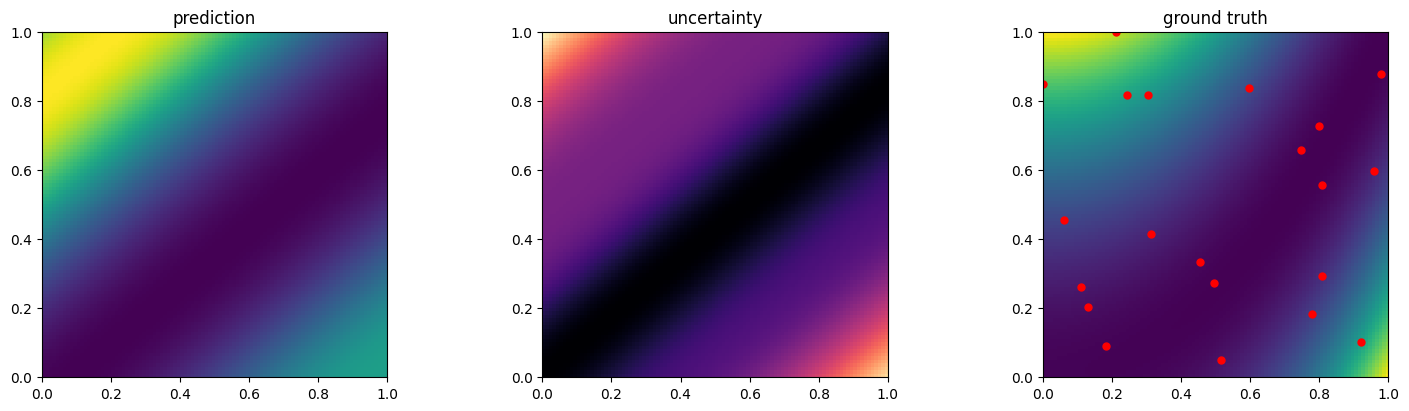

Step 1


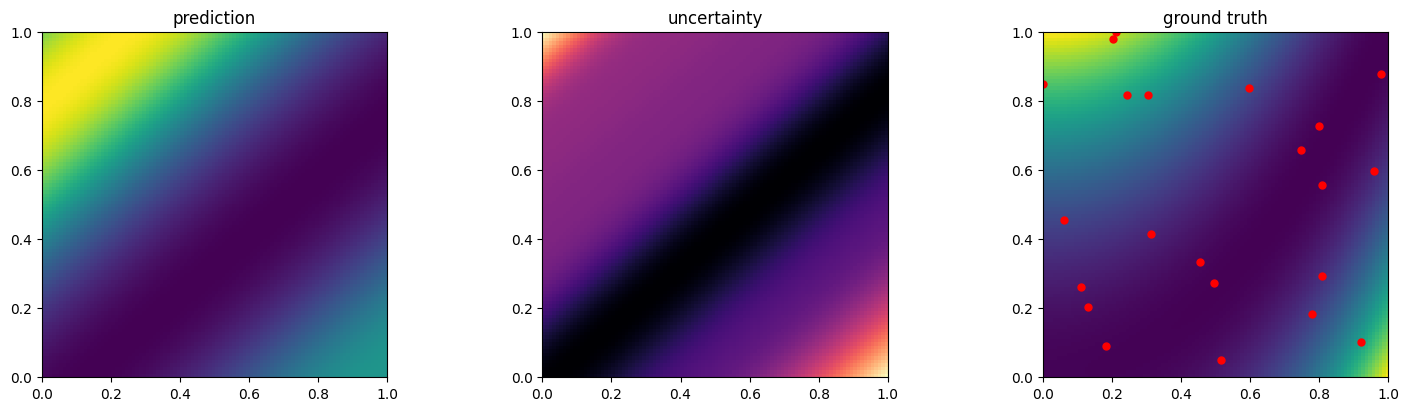

Step 2


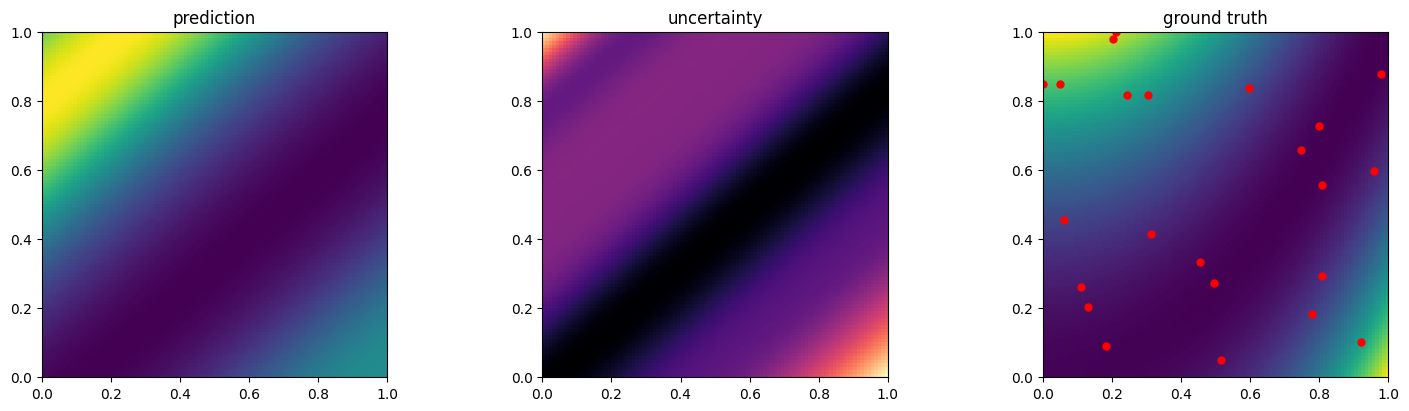

Step 3


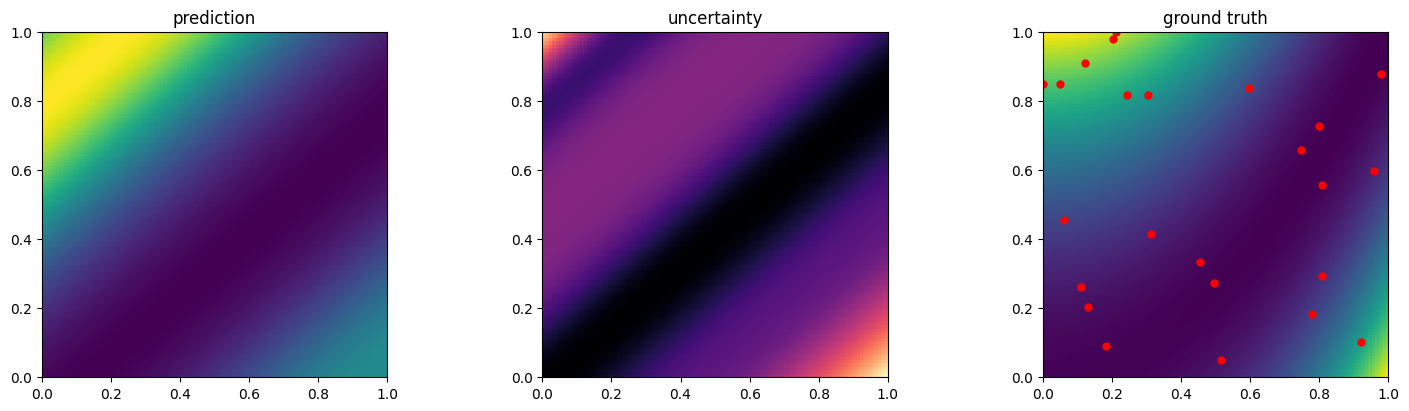

Step 4


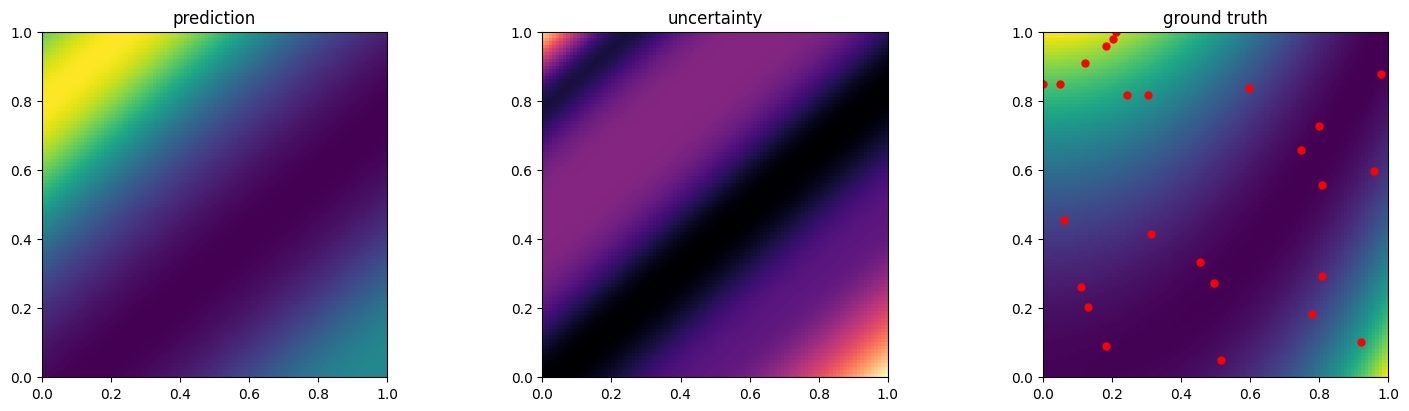

Step 5


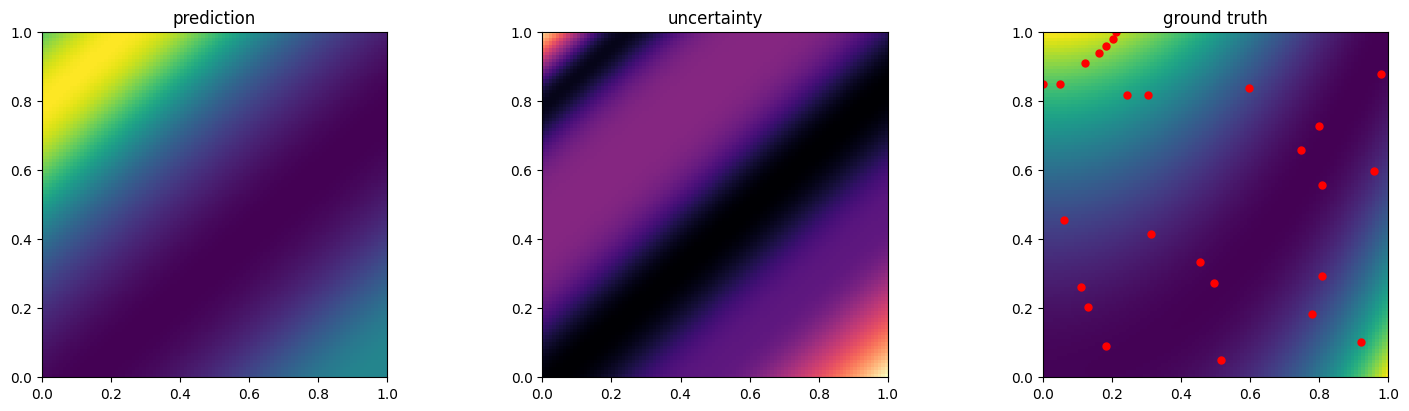

Step 6


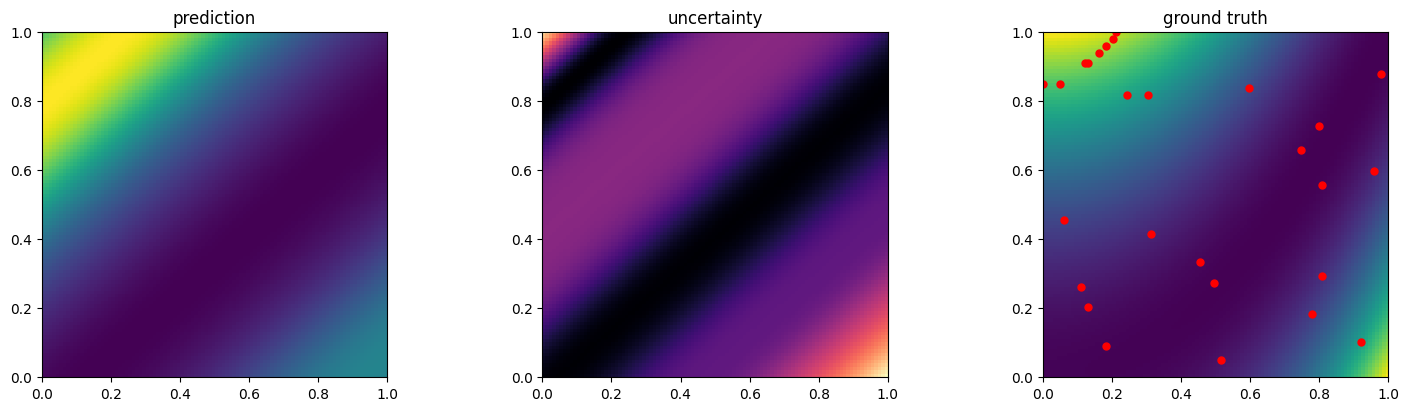

Step 7


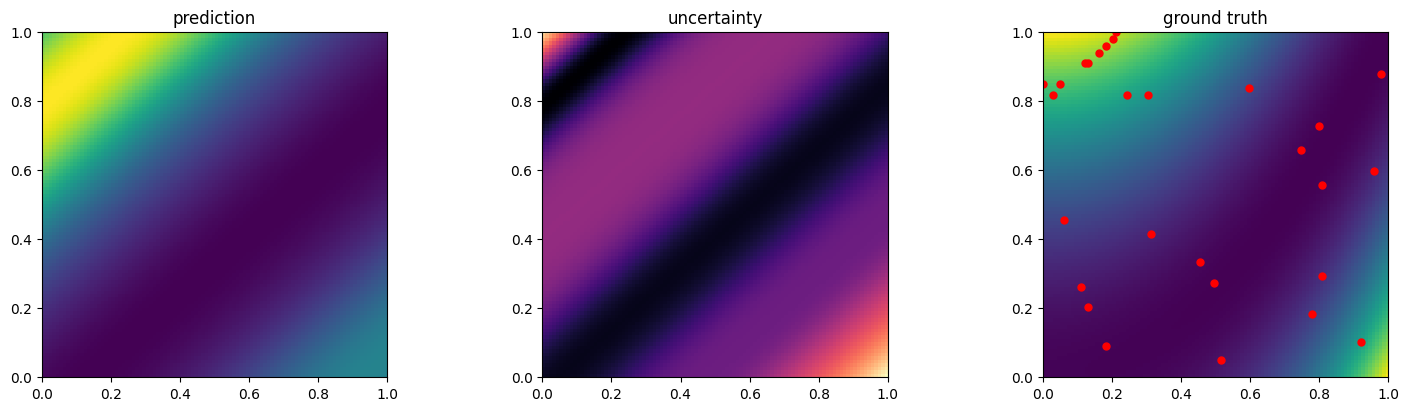

Step 8


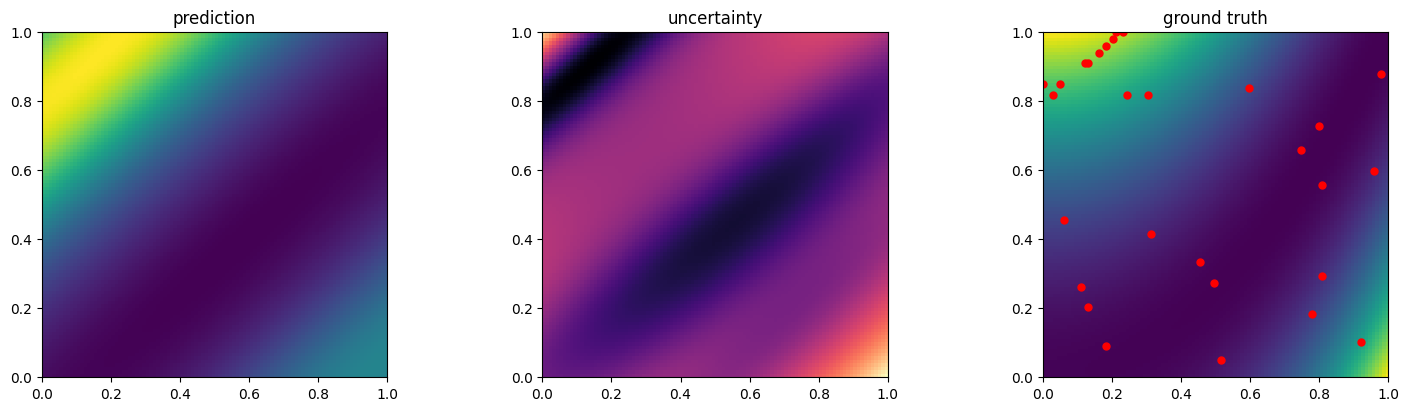

Step 9


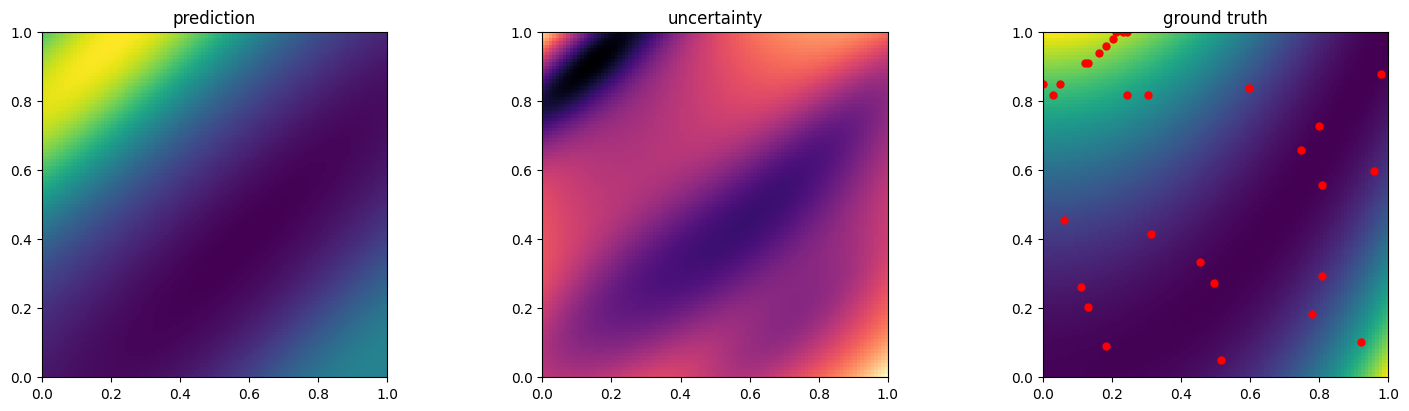

Step 10


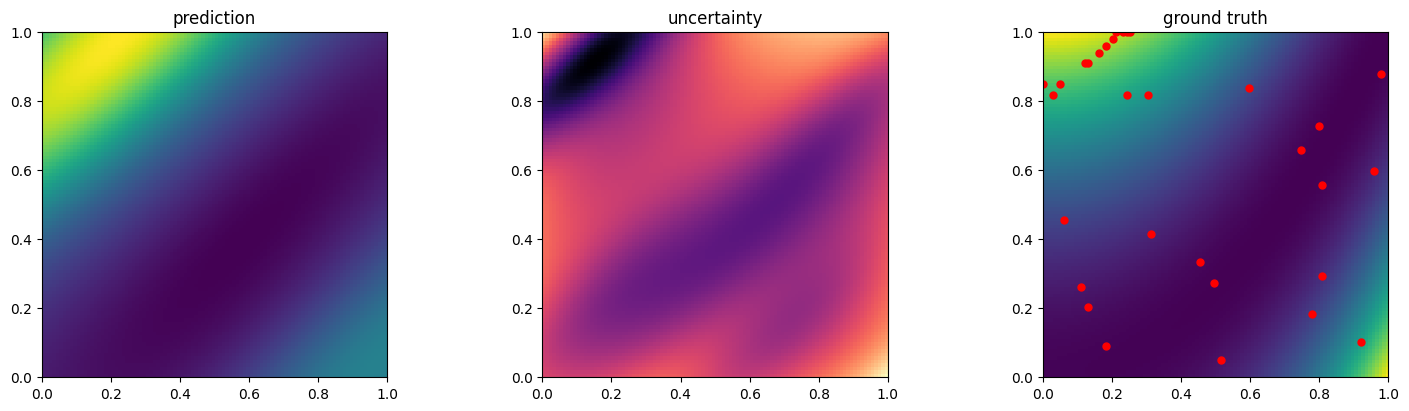

Step 11


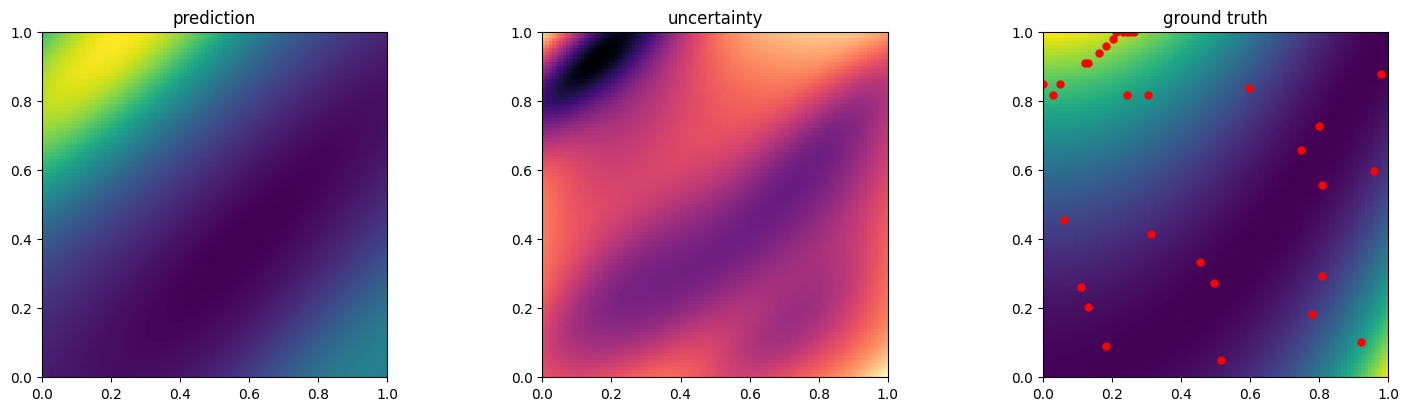

Step 12


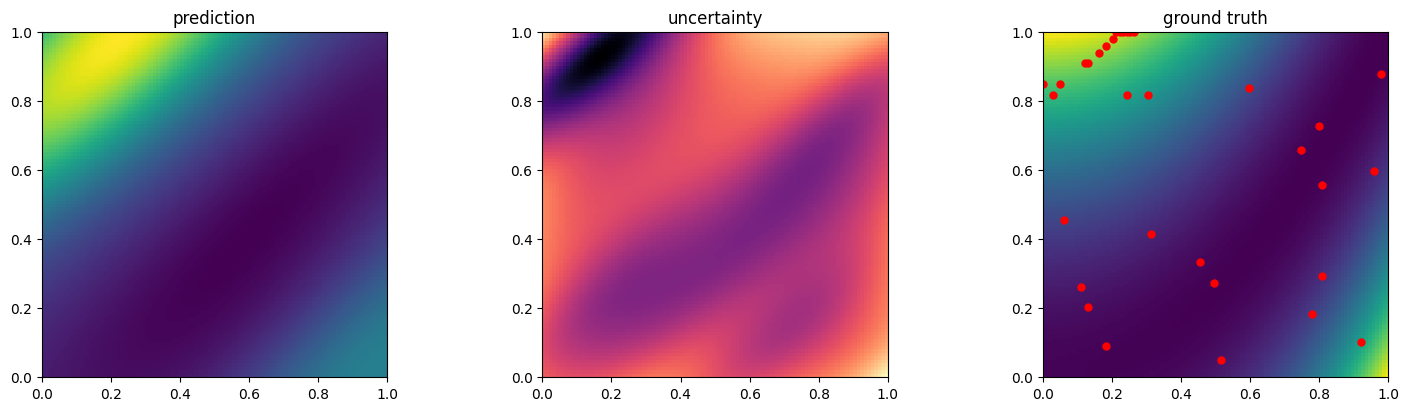

Step 13


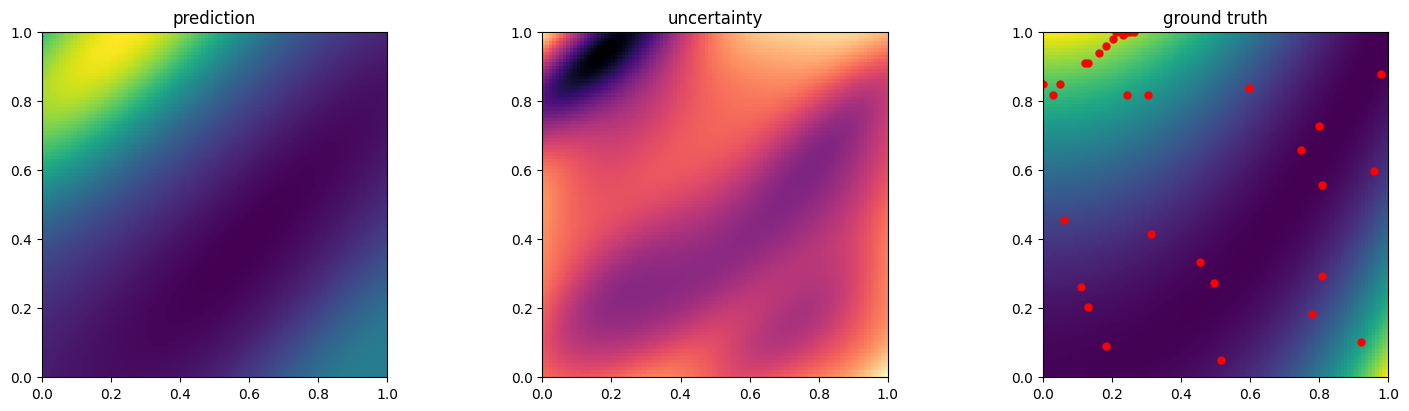

Step 14


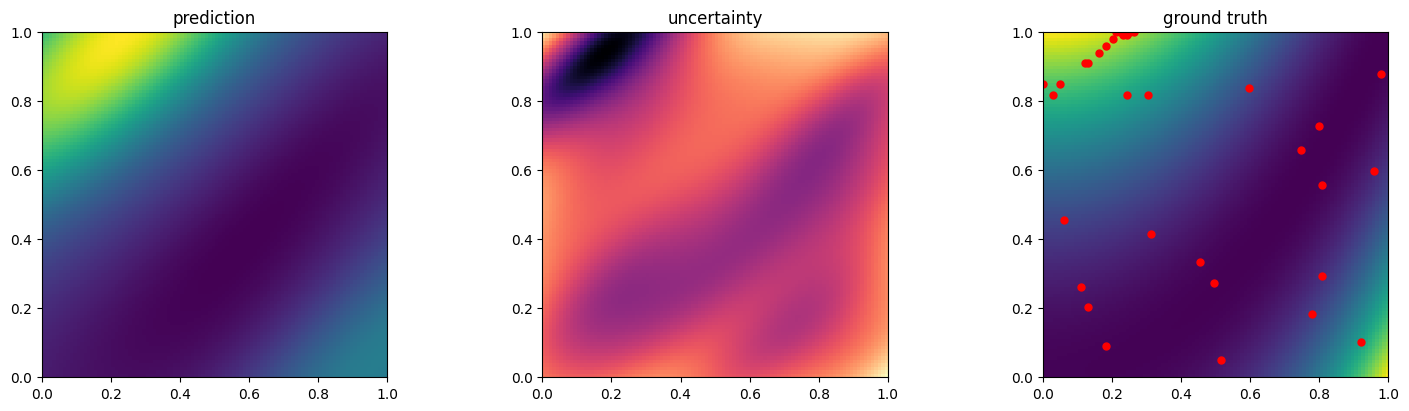

Step 15


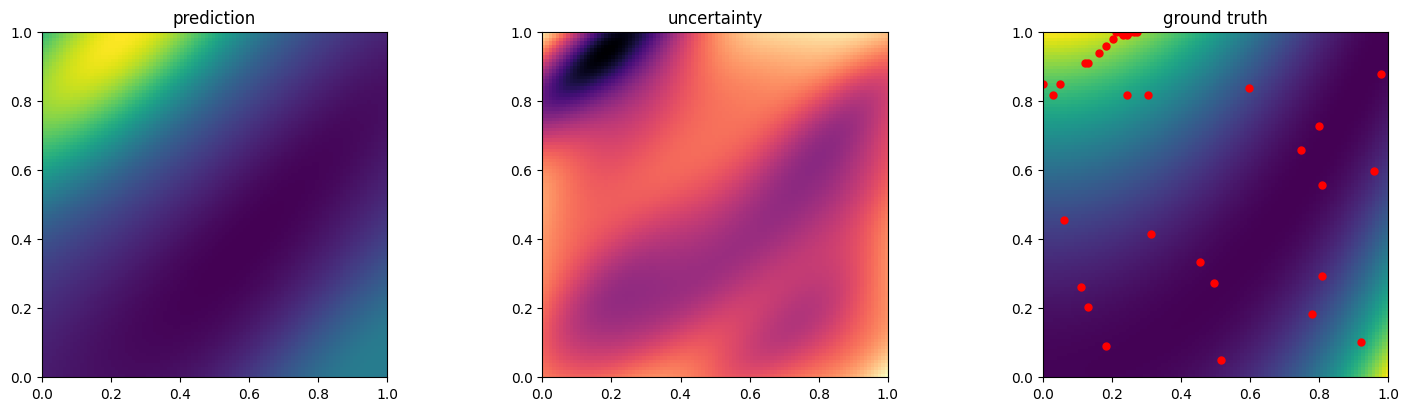

Step 16


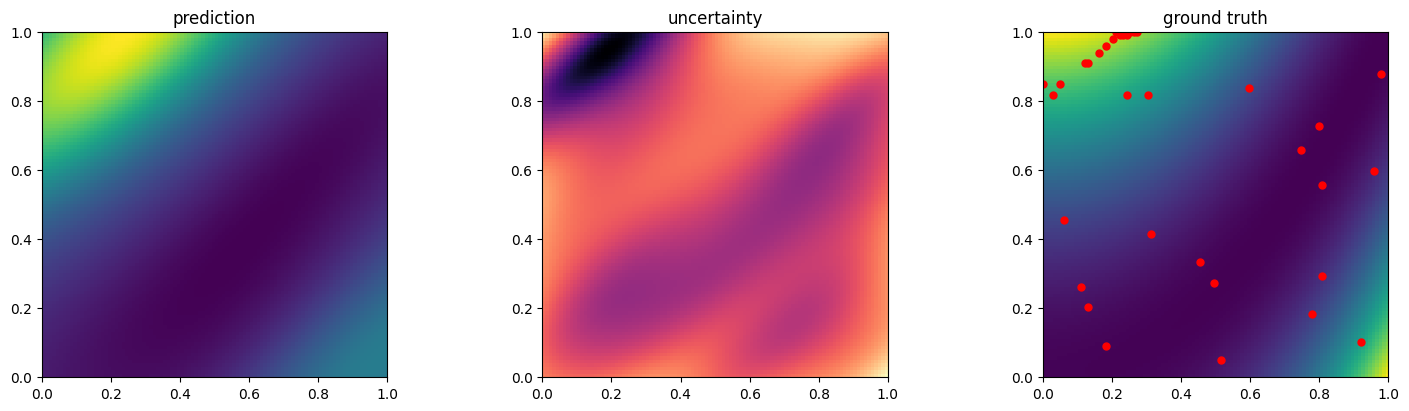

Step 17


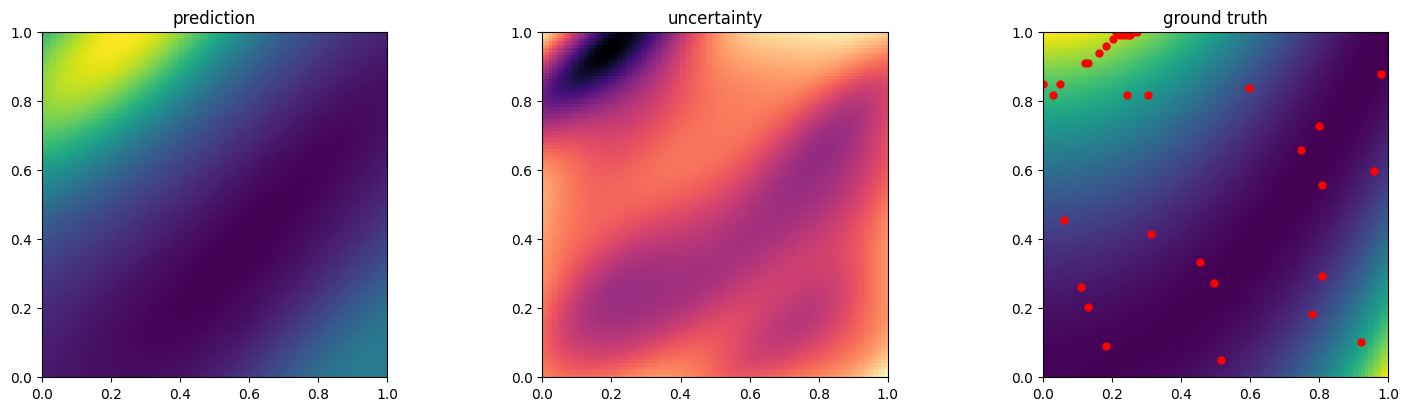

Step 18


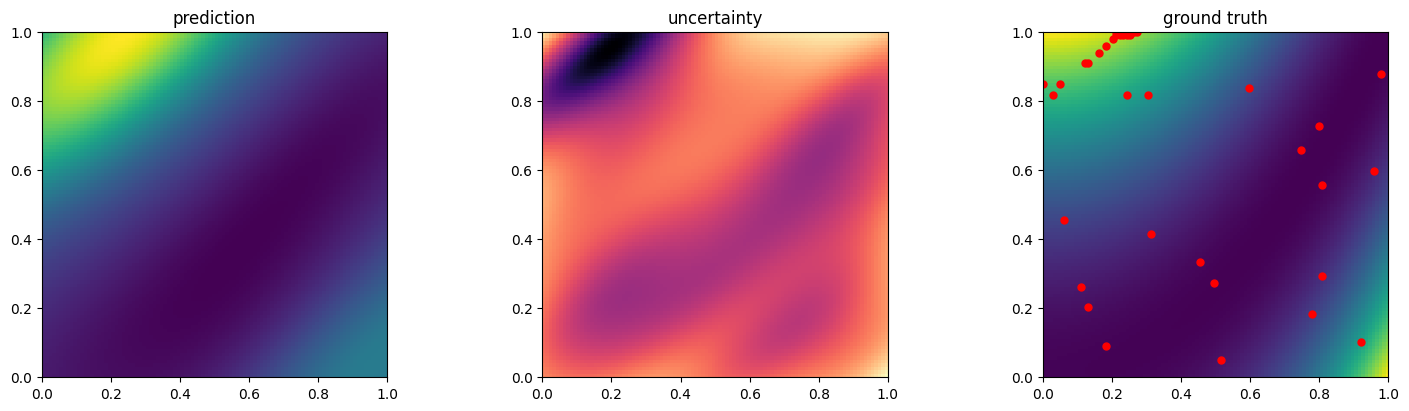

Step 19


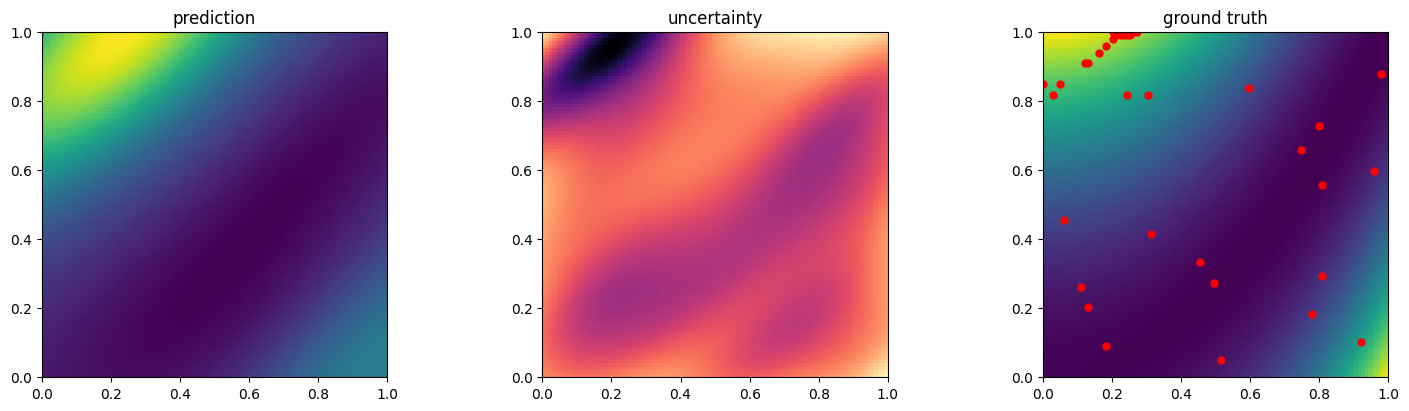

Step 20


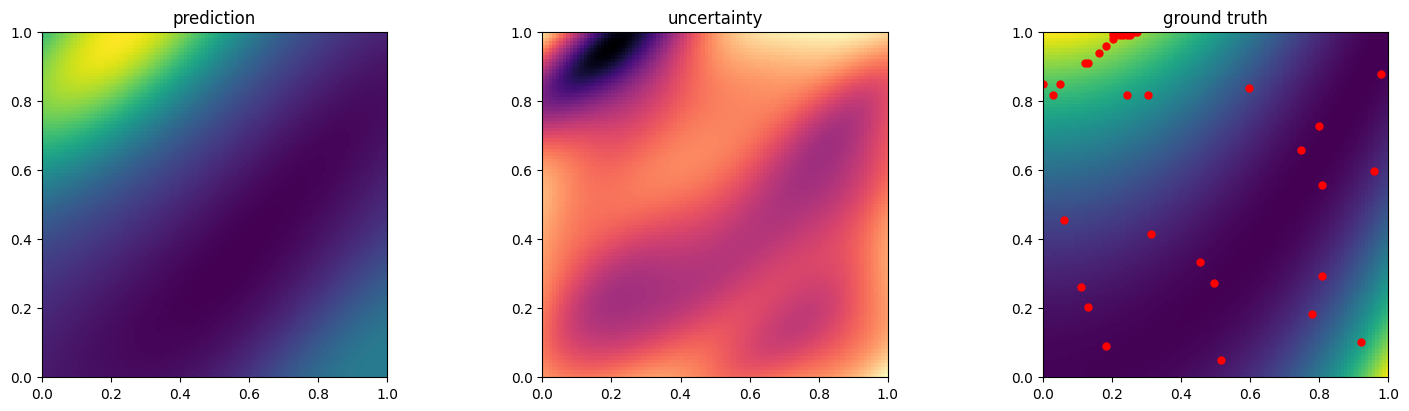

Step 21


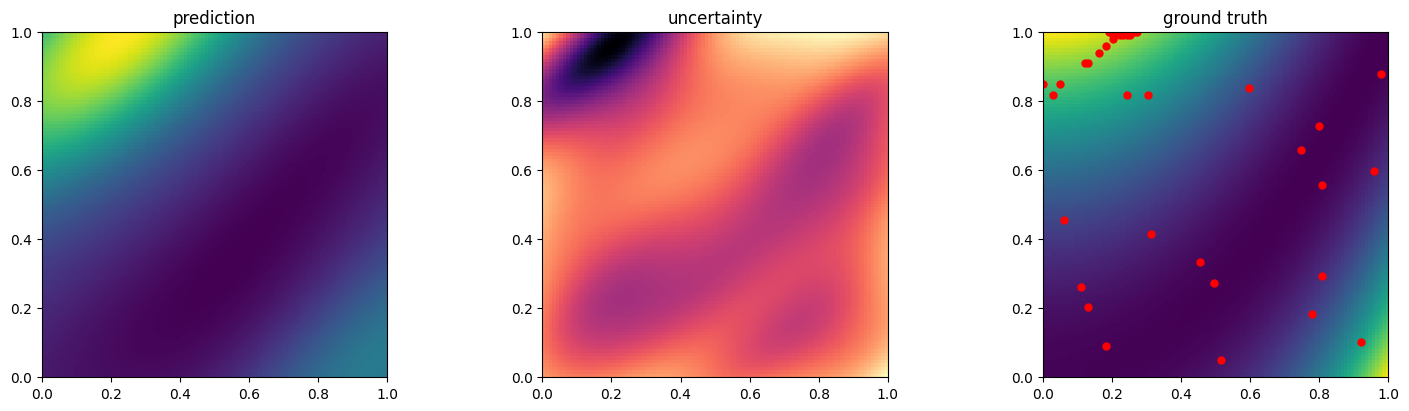

Step 22


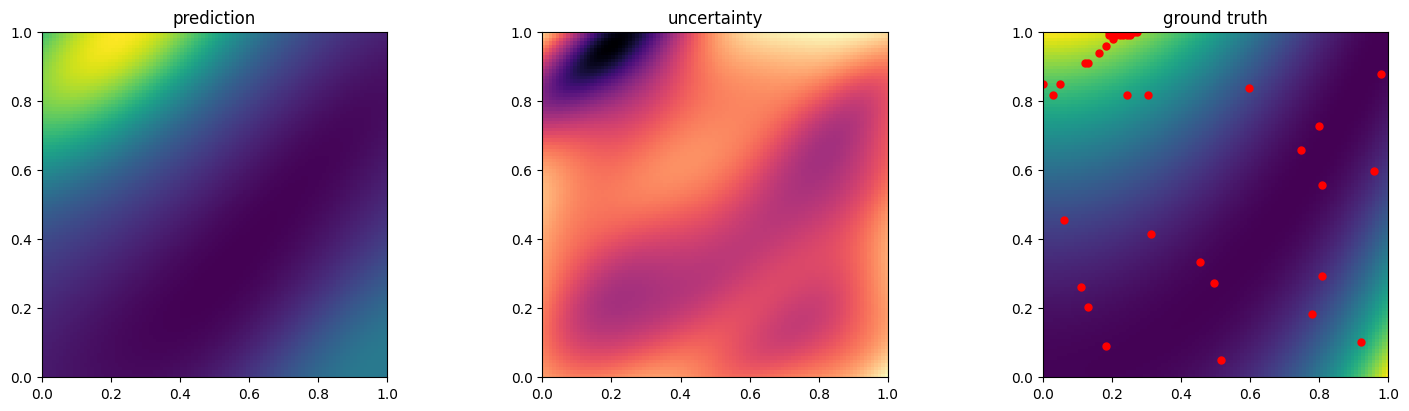

Step 23


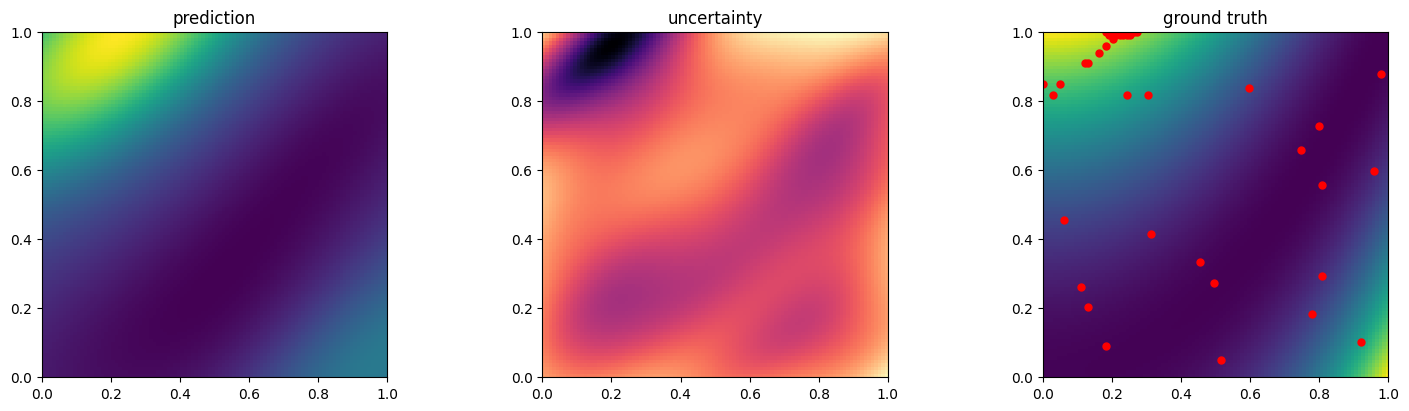

Step 24


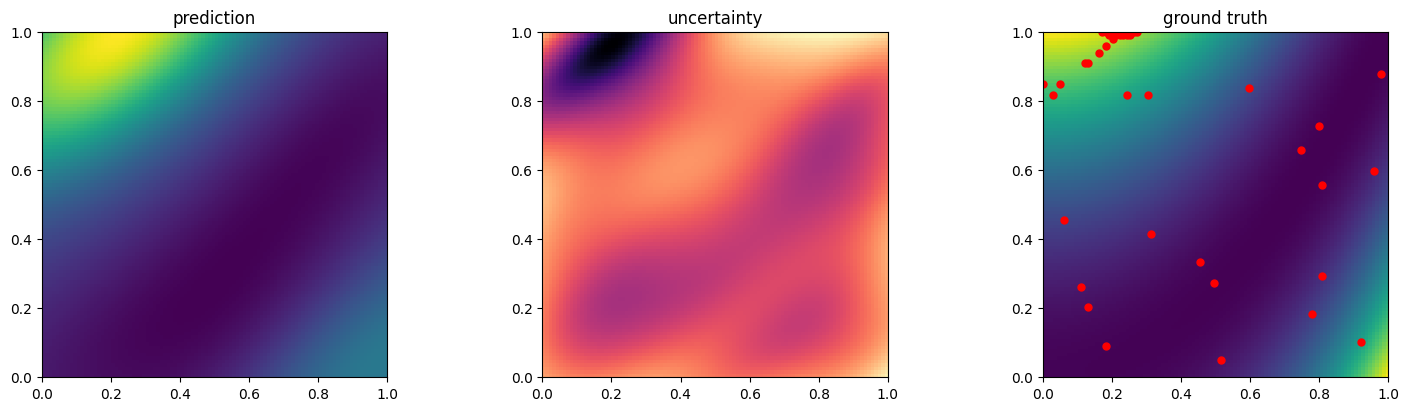

Final n_samples: 45
Best observed value: 94.90813557487574


In [220]:
# Active learning loop (UCB) using a pure GP kernel

# Choose which pure-GP kernel to use for acquisition modeling
al_kernel = 'direct_attention'   # 'rbf' | 'direct_attention' | 'attention_weighted'

n_init_al = 20
n_steps_al = 25
noise_std_al = 0.05

# Candidate set (NumPy)
X_all_np = grid_xy_np.copy()

# Ground-truth on grid (NumPy)
if objective == 'rosenbrock':
    y_all_np = rosenbrock(X_all_np[:, 0], X_all_np[:, 1])
elif objective == 'levy':
    y_all_np = levy(X_all_np[:, 0], X_all_np[:, 1])
else:
    raise ValueError(f'Unknown objective: {objective!r}')

# Init samples
rng_al = np.random.default_rng(SEED + 2)
init_idx = rng_al.choice(len(X_all_np), size=n_init_al, replace=False)
selected = set(int(i) for i in init_idx)

X_train_np = X_all_np[init_idx]
if objective == 'rosenbrock':
    y_true = rosenbrock(X_train_np[:, 0], X_train_np[:, 1])
else:
    y_true = levy(X_train_np[:, 0], X_train_np[:, 1])

y_obs_np = y_true + rng_al.normal(0.0, noise_std_al, size=y_true.shape)

history_best = []

for t in range(n_steps_al):
    print ("Step {}".format(t))
    # Fit pure GP model on current data
    mll, gp, model, losses = egp.fit_dkgp(
        torch.from_numpy(X_train_np),
        torch.from_numpy(y_obs_np),
        extractor_type=None,
        gp_kernel_type=al_kernel,
        num_epochs=3000,
        lr_gp=5e-3,
        device=device,
        verbose=False,
    )

    best_f = float(np.max(y_obs_np))
    history_best.append(best_f)

    # Acquire next point by maximizing UCB over remaining candidates
    ucb = egp.upper_confidence_bound(model, X_all_np, beta=5.0, device=device, maximize=True)

    ucb_masked = ucb.copy()
    for j in selected:
        ucb_masked[j] = -np.inf

    next_idx = int(np.argmax(ucb_masked))
    selected.add(next_idx)

    x_next = X_all_np[next_idx:next_idx+1]
    if objective == 'rosenbrock':
        y_next_true = rosenbrock(x_next[:, 0], x_next[:, 1])
    else:
        y_next_true = levy(x_next[:, 0], x_next[:, 1])

    y_next_obs = y_next_true + rng_al.normal(0.0, noise_std_al, size=y_next_true.shape)

    X_train_np = np.vstack([X_train_np, x_next])
    y_obs_np = np.concatenate([y_obs_np, y_next_obs])

    # Quick visualization (optional)
    mean, var = egp.predict_dkgpr(model, X_all_np, device=device)
    std = np.sqrt(var)
    Z_mean = mean.reshape(grid_size, grid_size)
    Z_std = std.reshape(grid_size, grid_size)

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    ax1.set_title('prediction')
    ax1.imshow(Z_mean, origin='lower', extent=(0, 1, 0, 1), cmap='viridis')
    ax1.set_aspect('equal')

    ax2.set_title('uncertainty')
    ax2.imshow(Z_std, origin='lower', extent=(0, 1, 0, 1), cmap='magma')
    ax2.set_aspect('equal')

    ax3.set_title('ground truth')
    ax3.imshow(y_all_np.reshape(grid_size, grid_size), origin='lower', extent=(0, 1, 0, 1), cmap='viridis')
    ax3.scatter(X_train_np[:, 0], X_train_np[:, 1], c='r', s=25)
    ax3.set_aspect('equal')
    plt.show()

print('Final n_samples:', len(X_train_np))
print('Best observed value:', np.max(y_obs_np))


### Active learning sample map

Shows where the algorithm sampled:
- initial random points
- subsequently acquired points

This is useful to see whether the acquisition focuses on informative regions (e.g., near minima or high-uncertainty areas).


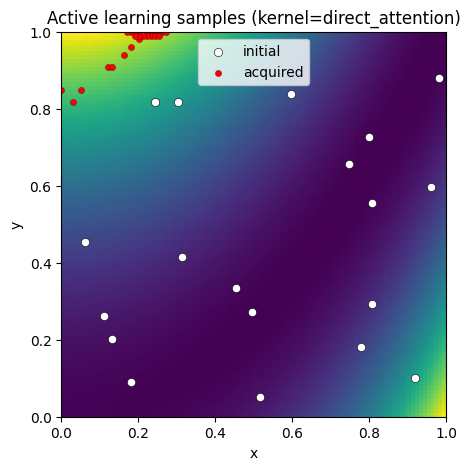

In [221]:
# Plot sampled locations (active learning)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(y_all_np.reshape(grid_size, grid_size), origin='lower', extent=(0, 1, 0, 1), cmap='viridis')

ax.scatter(X_train_np[:n_init_al, 0], X_train_np[:n_init_al, 1], c='white', s=35, edgecolor='k', linewidth=0.4, label='initial')
ax.scatter(X_train_np[n_init_al:, 0], X_train_np[n_init_al:, 1], c='red', s=20, edgecolor='k', linewidth=0.2, label='acquired')
ax.set_title(f'Active learning samples (kernel={al_kernel})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.legend()
plt.show()


### Best-so-far trace

Tracks the best observed objective value after each acquisition step.
This is a simple way to visualize progress during exploration.

Note: for minimization objectives, you may prefer tracking *minimum* instead of maximum.


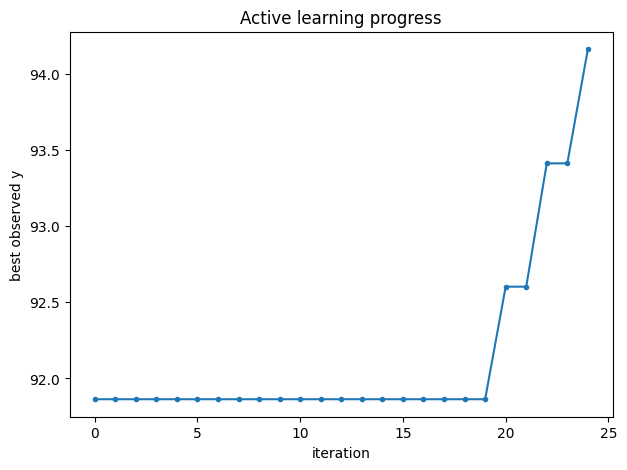

In [222]:
# Best-so-far over iterations

fig, ax = plt.subplots()
ax.plot(history_best, marker='o', markersize=3)
ax.set_xlabel('iteration')
ax.set_ylabel('best observed y')
ax.set_title('Active learning progress')
plt.show()
